```markdown
# ⚠️ Data Availability Notice

The data required to run this notebook is **not included** in this repository.

To access the dataset, you must request it from the authors of:

**"Homophily and minority-group size explain perception biases in social networks"**, by Eun Lee, Fariba Karimi, Claudia Wagner, Hang-Hyun Jo, Markus Strohmaier & Mirta Galesic 

After obtaining the data, place it in the appropriate `data/` directory before running this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

df_de = pd.read_excel('data\\Data_DE_fin.xlsx')
df_us = pd.read_excel('data\\Data_US_fin.xlsx')
df_kr = pd.read_excel('data\\Data_KR.xlsx')

C:\Users\Giovanni Palermo\AppData\Local\Programs\Python\Python312\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [2]:
columns_new = ['id', 'sex', 'age', 'edu', 'moneyfood', 'charity', 'theft', 'beliefgod',
       'godmoral', 'worship', 'religimport', 'smoking', 'military', 'gay',
       'circle', 'binsoc_intro2', 'binsoc_moneyfood', 'binsoc_charity',
       'binsoc_theft', 'binsoc_religimport', 'binsoc_worship', 'binsoc_godmoral',
       'binsoc_beliefgod', 'binsoc_gay', 'binsoc_military', 'binsoc_smoking',
       'binpop_intro2', 'binpop_moneyfood', 'binpop_charity', 'binpop_theft',
       'binpop_religimport', 'binpop_worship', 'binpop_godmoral',
       'binpop_beliefgod', 'binpop_gay', 'binpop_military', 'binpop_smoking',
       'datetime']
df_de.columns = columns_new
df_us.columns = columns_new

In [3]:
columns_fix = ['id', 'working', 'beliefgod', 'godmoral', 'worship', 'religimport', 'smoking', 'gay', 'moneyfood', 'charity',
       'binsoc_beliefgod', 'binsoc_godmoral', 'binsoc_worship', 'binsoc_religimport', 'binsoc_smoking', 'binsoc_gay', 'binsoc_moneyfood', 'binsoc_charity',
       'binpop_beliefgod', 'binpop_godmoral', 'binpop_worship', 'binpop_religimport', 'binpop_smoking', 'binpop_gay', 'binpop_moneyfood', 'binpop_charity',
       ]
df_kr.columns = columns_fix

In [4]:
issues = ['moneyfood', 'charity', 'theft', 'beliefgod', 'godmoral', 'worship', 'religimport', 'smoking', 'military', 'gay']
countries = ['Germany', 'United States', 'Korea']

In [5]:
for df in [df_de, df_us, df_kr]:
    for issue in issues:
        if issue not in df.columns:
            continue

        df[issue] = [1 if x == 1 else -1 for x in df[issue].values]
        df['binsoc_'+issue] = 2 * df['binsoc_'+issue] * 0.01 - 1
        df['binpop_'+issue] = 2 * df['binpop_'+issue] * 0.01 - 1

        if issue == 'worship' or issue == 'gay':
            df['binsoc_'+issue] = -df['binsoc_'+issue]
            df['binpop_'+issue] = -df['binpop_'+issue]

        # df['hom_'+issue] = 1 - abs(df[issue] - df['binsoc_'+issue]) * 0.5
        df['hom_'+issue] = [(1+x)*0.5 if y == 1 else (1 - x)*0.5 for x, y in zip(df['binsoc_'+issue].values, df[issue].values)]
for df, country in zip([df_de, df_us, df_kr], countries):
    df['country'] = country

df = pd.concat([df_de, df_us, df_kr], ignore_index=True)
#set country as first column
df = df[['country'] + [col for col in df.columns if col != 'country']]
df.to_csv('data\\Data_all_ready.csv', index=False)

In [6]:
gt_de = pd.read_excel('data\\Actual_DE.xlsx')
gt_us = pd.read_excel('data\\Actual_US.xlsx')
gt_kr = pd.read_excel('data\\Actual_KR.xlsx')

In [7]:
gt_de.dropna(inplace=True)
gt_us.dropna(inplace=True)
gt_kr.dropna(inplace=True)
gt_de.columns = issues
gt_us.columns = issues
gt_kr.columns = issues

In [8]:
df_res = pd.DataFrame(columns=['country', 'issue', 'normal', 'perc_avg', 'perc_unc', 'real', 'prediction_hom', 'prediction_hom_err', 'social_circle', 'social_circle_err', 'perc_avg_up', 'perc_avg_do', 'social_circle_up', 'social_circle_do'])

bootstrap=False

for df, gt, country in zip([df_de, df_us, df_kr], [gt_de, gt_us, gt_kr], countries):
    for issue in issues:
        if issue not in df.columns:
            continue

        if issue == 'godmoral' and country == 'Korea':
            continue
        
        N = len(df)
        normal = np.mean(df[issue].values)
        perc_unc = np.std(df['binpop_'+issue].values) / np.sqrt(len(df['binpop_'+issue].values))
        real = (gt[issue].values[0]-gt[issue].values[1]) / (gt[issue].values[0] + gt[issue].values[1])

        m = real
        perc_avg_up = np.mean(df[df[issue] == 1]['binpop_'+issue].values)
        perc_avg_do = np.mean(df[df[issue] == -1]['binpop_'+issue].values)
        perc_avg = perc_avg_up * (1+m) * 0.5 + perc_avg_do * (1-m) * 0.5
        social_circle_up = np.mean(df[df[issue] == 1]['binsoc_'+issue].values)
        social_circle_do = np.mean(df[df[issue] == -1]['binsoc_'+issue].values)
        # n_plus = len(df[df[issue] == 1]) / len(df)
        # n_minus = len(df[df[issue] == -1]) / len(df)
        n_plus = (1+m) * 0.5
        n_minus = (1-m) * 0.5
        social_circle = social_circle_up * n_plus + social_circle_do * n_minus
        social_circle_up_err = np.std(df[df[issue] == 1]['binsoc_'+issue].values, ddof=1) / np.sqrt(len(df[df[issue] == 1]['binsoc_'+issue].values))
        social_circle_do_err = np.std(df[df[issue] == -1]['binsoc_'+issue].values, ddof=1) / np.sqrt(len(df[df[issue] == -1]['binsoc_'+issue].values))
        social_circle_err = n_plus * social_circle_up_err + n_minus * social_circle_do_err
        
        prediction = (social_circle_up + social_circle_do) / (2 - social_circle_up + social_circle_do)
        prediction_err = 2 / (2 - social_circle_up + social_circle_do)**2 * ((1+social_circle_do)*social_circle_up_err + (1-social_circle_up)*social_circle_do_err)

        # print(perc_avg, real, prediction)
        new_row = {'country': country, 'issue': issue, 'normal': normal, 'perc_avg': perc_avg, 'perc_unc': perc_unc, 'real': real,
                                'prediction_hom': prediction, 'prediction_hom_err': prediction_err,
                                 'social_circle': social_circle, 'social_circle_err': social_circle_err,
                                'perc_avg_up': perc_avg_up, 'perc_avg_do': perc_avg_do, 'social_circle_up': social_circle_up, 'social_circle_do': social_circle_do}
        
        df_res.loc[len(df_res)] = new_row

In [9]:
df_res

,country,issue,normal,perc_avg,perc_unc,real,prediction_hom,prediction_hom_err,social_circle,social_circle_err,perc_avg_up,perc_avg_do,social_circle_up,social_circle_do
0,Germany,moneyfood,-0.393939,-0.715083,0.030784,-0.880000,-0.909229,0.034531,-0.905107,0.030241,-0.447333,-0.732174,-0.640000,-0.922029
1,Germany,charity,-0.454545,-0.532963,0.032311,-0.120000,-0.627785,0.061085,-0.531541,0.063201,-0.468148,-0.583889,-0.319259,-0.698333
2,Germany,theft,-0.515152,-0.642666,0.036904,-0.797980,-0.811422,0.044481,-0.809309,0.038009,-0.395833,-0.670400,-0.526667,-0.841067
3,Germany,beliefgod,-0.414141,0.015003,0.041012,-0.360000,-0.121619,0.095183,-0.190267,0.063061,0.148276,-0.047714,0.201379,-0.374571
4,Germany,godmoral,0.878788,-0.411792,0.042720,0.333333,-0.261082,0.070787,-0.412115,0.075389,-0.472688,-0.290000,-0.581505,-0.073333
5,Germany,worship,-0.797980,0.474737,0.035385,0.800000,0.365005,0.122060,0.238270,0.196598,0.476000,0.463371,0.180000,0.762697
6,Germany,religimport,-0.717172,-0.232073,0.035177,-0.212121,-0.528209,0.068826,-0.449687,0.062784,-0.175714,-0.268706,-0.148571,-0.645412
7,Germany,smoking,-0.737374,-0.223814,0.033092,-0.560000,-0.254316,0.113335,-0.320043,0.073131,-0.173846,-0.237907,0.015385,-0.414651
8,Germany,military,0.656566,0.042303,0.040034,0.000000,-0.051500,0.117461,-0.033472,0.074719,0.230488,-0.145882,0.316585,-0.383529
9,Germany,gay,0.878788,0.300611,0.048923,0.775510,0.437151,0.155437,0.485922,0.095645,0.302796,0.283333,0.518280,0.230000


In [10]:
def plot_country_bars_err_fisher(df, save=False):
    """
    Plot horizontal bar charts of estimator errors per country in Fisher z-space.
    Differences and error bars are Fisher-transformed for bounded quantities.
    """
    # Fisher transform helper
    def fisher(r):
        return np.arctanh(r)

    def fisher_sigma(r, sigma_r):
        return sigma_r / (1 - r**2)
    
    for country, group in df.groupby('country'):
        group = group.copy()
        
        # Transform all relevant columns to Fisher space
        group['perc_avg_z'] = fisher(group['perc_avg'])
        group['prediction_z'] = fisher(group['prediction_hom'])
        group['prediction_sc_z'] = fisher(group['social_circle'])
        group['real_z'] = fisher(group['real'])
        
        # Propagate uncertainties
        group['prediction_err_z'] = fisher_sigma(group['prediction_hom'], group['prediction_hom_err'])
        group['social_circle_err_z'] = fisher_sigma(group['social_circle'], group['social_circle_err'])
        
        # Differences in Fisher space
        group['diff_perc_avg'] = group['perc_avg_z'] - group['real_z']
        group['diff_prediction'] = group['prediction_z'] - group['perc_avg_z']
        group['diff_prediction_sc'] = group['prediction_sc_z'] - group['perc_avg_z']
        
        group = group.sort_values('diff_prediction', ascending=False)
        
        y = np.arange(len(group))
        height = 0.35

        fig, ax = plt.subplots(figsize=(8, 12))

        # Axes styling
        for spine in ['top','right','bottom','left']:
            ax.spines[spine].set_visible(True)
            ax.spines[spine].set_color('black')
            ax.spines[spine].set_linewidth(1)
        ax.set_facecolor("white")
        fig.patch.set_facecolor("white")

        # First bar: homophily vs perception
        ax.barh(y - height/2, group['diff_prediction'], height,
                xerr=group['prediction_err_z'], capsize=4,
                label='Homophily – Perception',
                color='#c95917', ecolor='#c95917', alpha=0.6)

        # Second bar: social circle vs perception
        ax.barh(y + height/2, group['diff_prediction_sc'], height,
                xerr=group['social_circle_err_z'], capsize=4,
                label='Social circle – Perception',
                color='#02503b', ecolor='#02503b', alpha=0.6)

        # Titles, labels
        country_name = country.capitalize()
        if country_name == 'Korea':
            country_name = 'South Korea'
        elif country_name == 'United states':
            country_name = 'United States'

        ax.set_title(country_name, fontsize=28)
        ax.set_yticks(y)
        ax.set_yticklabels(group['issue'], fontsize=20)
        ax.set_xlabel('Estimator error (Fisher z)', fontsize=22)
        ax.tick_params(axis='x', labelsize=20)

        # Optional: adjust x-limits depending on Fisher scale
        # For small correlations, -0.5 to 0.5 is reasonable; adjust as needed
        # ax.set_xlim(-0.5, 0.5)
        # ax.set_xlim(-0.8, 0.4)

        # Gridlines
        ax.grid(True, axis='x', color='gray', alpha=0.6, zorder=0)

        plt.tight_layout()
        if save:
            plt.savefig(f'graphs\\{country_name}_bars_err_fisher.pdf', dpi=300, bbox_inches="tight", pad_inches=0.01)
        plt.show()

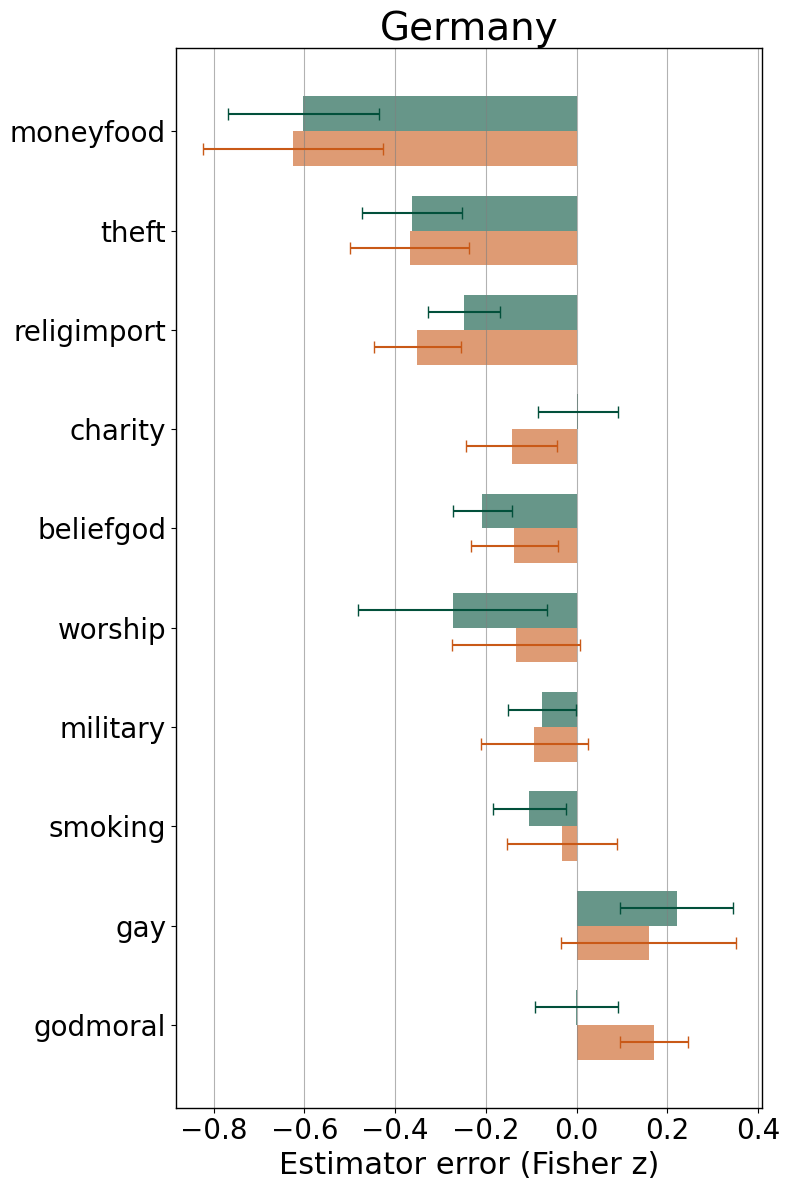

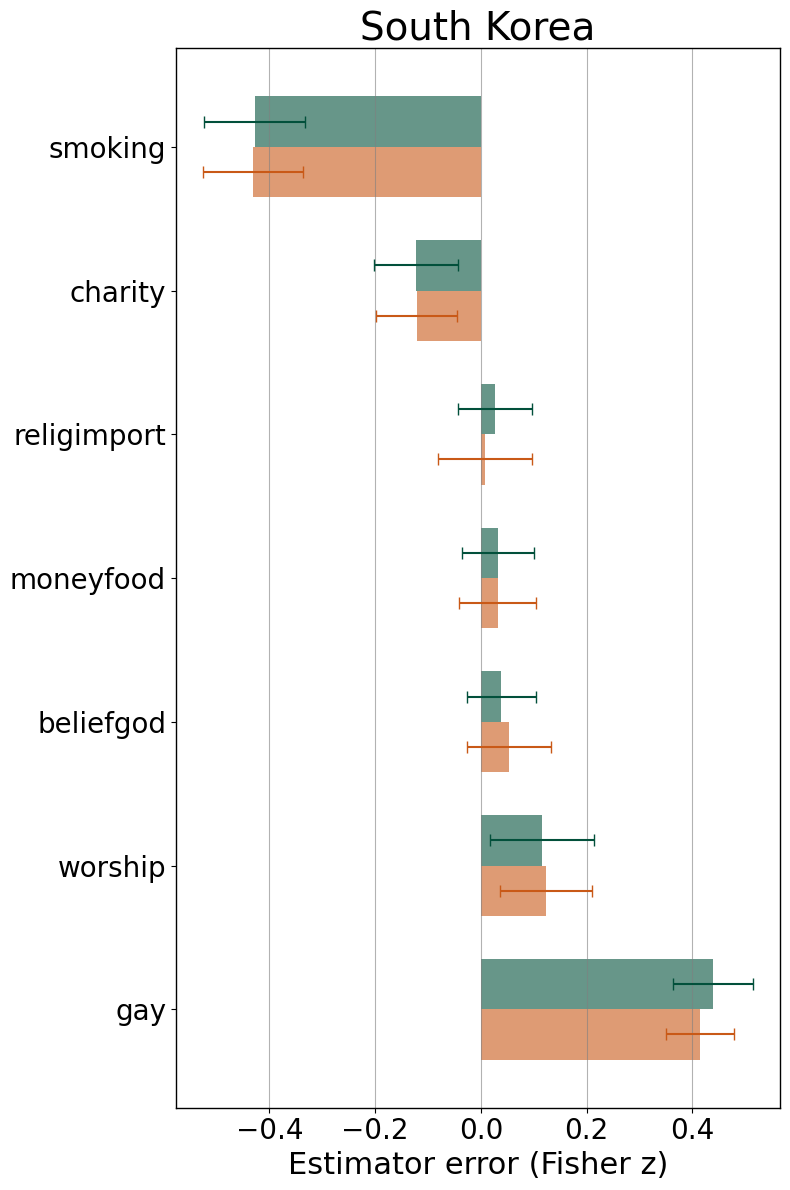

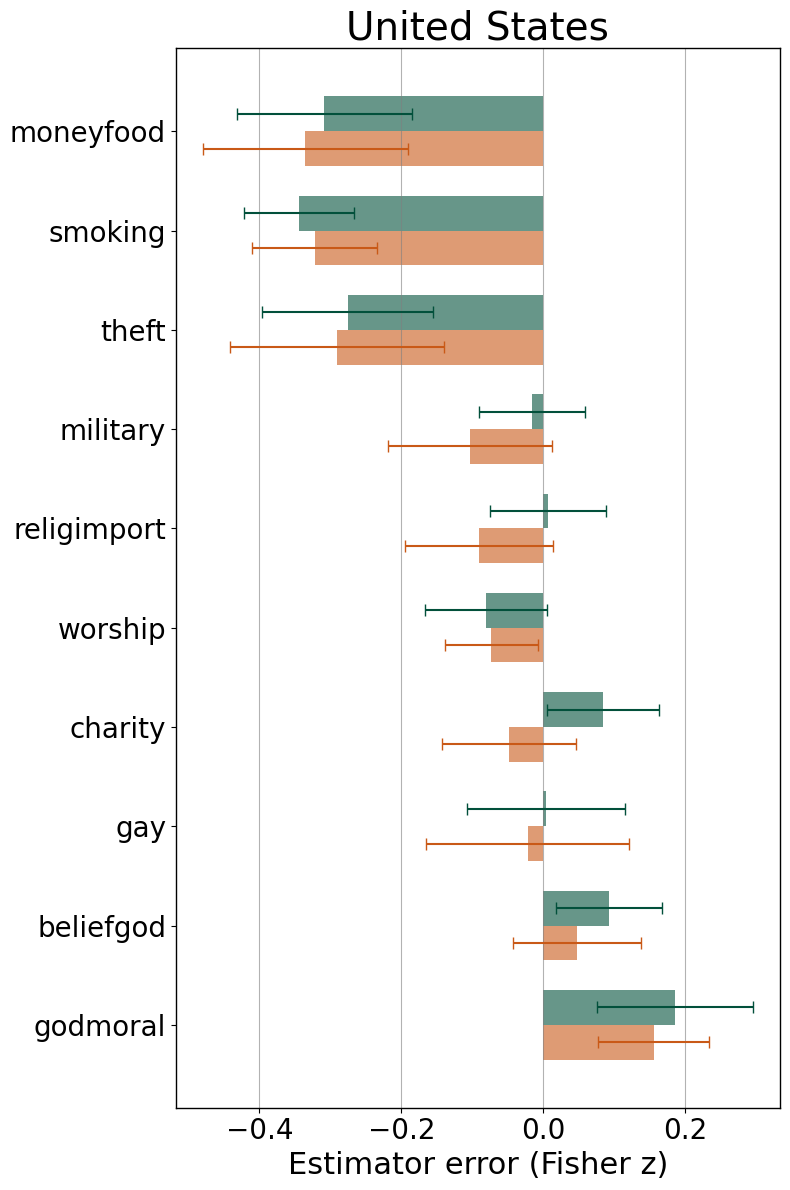

In [11]:
plot_country_bars_err_fisher(df_res, save=False)

In [12]:
import numpy as np
from scipy import stats

# Fisher helpers
def fisher_transform(r):
    return np.arctanh(r)

def propagate_fisher_sigma(r, sigma_r):
    return sigma_r / (1 - r**2)

def estimator_fisher_diagnostics_with_truth_uncertainty(
    df,
    estimator_cols=['social_circle', 'prediction'],
    truth_col='perc_avg',
    truth_err_col='perc_avg_err',
    err_cols=['social_circle_err','prediction_err'],
    alpha=0.1
):
    """
    Diagnostics including uncertainty on both estimator and truth.
    Computes chi2, bias, precision, MSE, correlation, and significance tests.
    """
    countries = df['country'].unique()
    all_results = {}
    
    def compute_metrics(sub_df):
        metrics = {}
        chi2_dict = {}
        
        # Transform truth
        truth_r = sub_df[truth_col].values
        truth_sigma = sub_df[truth_err_col].values
        truth_z = fisher_transform(truth_r)
        sigma_z_truth = propagate_fisher_sigma(truth_r, truth_sigma)
        
        for est_col, err_col in zip(estimator_cols, err_cols):
            r_est = sub_df[est_col].values
            sigma_est = sub_df[err_col].values
            z_est = fisher_transform(r_est)
            sigma_z_est = propagate_fisher_sigma(r_est, sigma_est)
            
            # Total propagated uncertainty (estimator + truth, independent)
            sigma_total = np.sqrt(sigma_z_est**2 + sigma_z_truth**2)
            
            # Errors in z-space
            errors = z_est - truth_z
            chi2_contrib = (errors / sigma_total)**2
            chi2_red = np.mean(chi2_contrib)
            
            # Bias, precision, MSE
            bias = np.mean(errors)
            precision = np.mean(sigma_total)
            var_err = np.var(errors, ddof=1)
            mse = bias**2 + var_err
            
            # Pearson correlation in original r-space
            corr, _ = stats.pearsonr(r_est, truth_r)
            
            metrics[est_col] = {
                'chi2_reduced': chi2_red,
                'correlation': corr,
                'bias': bias,
                'precision': precision,
                'MSE': mse,
                'errors_z': errors,
                'sigma_total_z': sigma_total
            }
            chi2_dict[est_col] = chi2_contrib
        
        return metrics
    
    # --- Overall
    all_results['Overall'] = compute_metrics(df)
    
    # --- By country
    for c in countries:
        df_country = df[df['country'] == c]
        all_results[c] = compute_metrics(df_country)
    
    # --- Print nicely
    for loc, metrics in all_results.items():
        print(f"\n📊 Results for {loc}:")
        header = f"{'Estimator':<20}{'Corr':>8}{'Chi2_red':>10}{'Bias':>10}{'Precision':>12}{'MSE':>10}"
        print(header)
        print('-'*len(header))
        for est_col in estimator_cols:
            m = metrics[est_col]
            print(f"{est_col:<20}{m['correlation']:>8.3f}{m['chi2_reduced']:>10.3f}"
                  f"{m['bias']:>10.3f}{m['precision']:>12.3f}{m['MSE']:>10.3f}")

In [13]:
estimator_fisher_diagnostics_with_truth_uncertainty(
    df_res,
    estimator_cols=['prediction_hom', 'social_circle'],
    truth_col='perc_avg',
    truth_err_col='perc_unc',
    err_cols=['prediction_hom_err', 'social_circle_err']
)


📊 Results for Overall:
Estimator               Corr  Chi2_red      Bias   Precision       MSE
----------------------------------------------------------------------
prediction_hom         0.944     4.175    -0.095       0.116     0.058
social_circle          0.937     4.430    -0.082       0.105     0.057

📊 Results for Germany:
Estimator               Corr  Chi2_red      Bias   Precision       MSE
----------------------------------------------------------------------
prediction_hom         0.956     3.614    -0.156       0.136     0.083
social_circle          0.953     4.129    -0.165       0.120     0.079

📊 Results for United States:
Estimator               Corr  Chi2_red      Bias   Precision       MSE
----------------------------------------------------------------------
prediction_hom         0.962     2.576    -0.108       0.115     0.038
social_circle          0.951     3.166    -0.065       0.102     0.038

📊 Results for Korea:
Estimator               Corr  Chi2_red      Bias